In [1]:
%cd NISP-Dataset/Hindi_master

/data/himanshu/NISP-Dataset/Hindi_master


/home/himanshu/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import pandas as pd
noisy_df = pd.read_csv("/data/himanshu/NISP-Dataset/noisy_dataset.csv")

In [3]:
noisy_df.head()

,File_Path,Native_State
0,../Merged_Audio_Noisy/Hin_0092_Hin_f_0008.wav,Uttar_Pradesh
1,../Merged_Audio_Noisy/Hin_0077_Eng_f_7341.wav,Maharashtra
2,../Merged_Audio_Noisy/Hin_0093_Hin_f_0023.wav,Maharashtra
3,../Merged_Audio_Noisy/Hin_0020_Eng_m_5447.wav,Uttar_Pradesh
4,../Merged_Audio_Noisy/Hin_0013_Eng_m_5222.wav,Bihar


In [4]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import soundfile as sf

from datasets import Dataset
from transformers import (
    AutoProcessor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Rename columns for consistency
df = noisy_df.rename(columns={
    "File_Path": "file_path",
    "Native_State": "label_text"
})

dataset = Dataset.from_pandas(df)

In [6]:
df.shape

(7839, 2)

In [7]:
labels = sorted(df["label_text"].unique())

label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

def encode_labels(batch):
    batch["label"] = label2id[batch["label_text"]]
    return batch

dataset = dataset.map(encode_labels)

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

In [ ]:
print(label2id)

In [8]:
def load_audio(batch):
    audio, _ = librosa.load(batch["file_path"], sr=16000)
    batch["audio"] = audio
    return batch

dataset = dataset.map(load_audio)

Map:   0%|          | 0/7839 [00:00<?, ? examples/s]

/usr/lib/python3/dist-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/usr/lib/python3/dist-packages/paramiko/transport.py:261: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


In [9]:
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset["train"]
val_dataset = dataset["test"]

In [11]:
from transformers import Wav2Vec2FeatureExtractor

processor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/wav2vec2-xls-r-300m"
)

In [12]:
from transformers import (
    Wav2Vec2FeatureExtractor,
    AutoModelForAudioClassification
)

model_name = "facebook/wav2vec2-xls-r-300m"

processor = Wav2Vec2FeatureExtractor.from_pretrained(model_name)

model = AutoModelForAudioClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label
)

model.freeze_feature_encoder()

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-xls-r-300m and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
import numpy as np

TARGET_LENGTH = 16000 * 10  # 10 seconds (160k samples)

def preprocess(batch):
    audio = batch["audio"]

    # 🔹 Case 1: Audio longer than 10 sec → Random crop (recommended)
    if len(audio) > TARGET_LENGTH:
        start = np.random.randint(0, len(audio) - TARGET_LENGTH)
        audio = audio[start:start + TARGET_LENGTH]

    # 🔹 Case 2: Audio shorter than 10 sec → Pad with zeros
    elif len(audio) < TARGET_LENGTH:
        pad_length = TARGET_LENGTH - len(audio)
        audio = np.pad(audio, (0, pad_length), mode='constant')

    # 🔹 Convert to model input
    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    batch["input_values"] = inputs.input_values[0]
    return batch

In [14]:
train_dataset = train_dataset.map(
    preprocess,
    remove_columns=["audio", "file_path", "label_text"]
)

val_dataset = val_dataset.map(
    preprocess,
    remove_columns=["audio", "file_path", "label_text"]
)

Map:   0%|          | 0/6271 [00:00<?, ? examples/s]

Map:   0%|          | 0/1568 [00:00<?, ? examples/s]

In [15]:
from dataclasses import dataclass
from typing import List, Dict

@dataclass
class DataCollator:
    processor: AutoProcessor

    def __call__(self, features: List[Dict]):
        input_values = [f["input_values"] for f in features]
        labels = [f["label"] for f in features]

        batch = self.processor.pad(
            {"input_values": input_values},
            return_tensors="pt",
            padding=True
        )

        batch["labels"] = torch.tensor(labels)
        return batch

data_collator = DataCollator(processor)

In [16]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        logits = predictions[0]
    else:
        logits = predictions

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    accuracy = accuracy_score(labels, preds)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [17]:
training_args = TrainingArguments(
    output_dir="./xlsr-dialect",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    num_train_epochs=10,
    learning_rate=1e-4,
    warmup_steps=500,
    fp16=True,
    save_total_limit=2
)

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=processor,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/home/himanshu/.local/lib/python3.10/site-packages/accelerate/accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.556000,2.540301,0.203444,0.068785,0.041389,0.203444
2,2.540400,2.546352,0.203444,0.068785,0.041389,0.203444
3,2.379600,2.335381,0.221939,0.123445,0.088519,0.221939
4,1.952100,1.735301,0.394133,0.330594,0.329910,0.394133
5,1.200800,1.063116,0.649235,0.622900,0.658237,0.649235
6,0.716900,0.547159,0.834184,0.827955,0.856490,0.834184
7,0.345500,0.341827,0.910714,0.909248,0.915251,0.910714
8,0.186100,0.256447,0.943878,0.943973,0.947164,0.943878
9,0.210100,0.180551,0.964923,0.965049,0.966237,0.964923
10,0.162000,0.143181,0.973852,0.973864,0.974129,0.973852


/home/himanshu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/himanshu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/himanshu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/himanshu/.

TrainOutput(global_step=7840, training_loss=1.3156262724071133, metrics={'train_runtime': 11619.9902, 'train_samples_per_second': 5.397, 'train_steps_per_second': 0.675, 'total_flos': 1.90060065102048e+19, 'train_loss': 1.3156262724071133, 'epoch': 10.0})

In [20]:
import torch
torch.cuda.empty_cache()

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

In [21]:
train_outputs = trainer.predict(train_dataset)

if isinstance(train_outputs.predictions, tuple):
    train_logits = train_outputs.predictions[0]
else:
    train_logits = train_outputs.predictions

train_labels = train_outputs.label_ids
train_preds = np.argmax(train_logits, axis=-1)

train_accuracy = accuracy_score(train_labels, train_preds)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9974


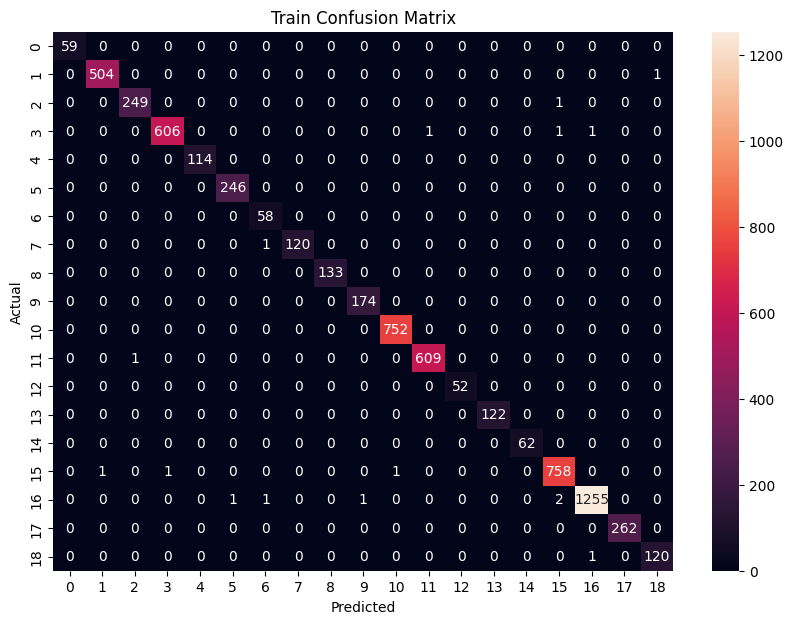

In [22]:
cm_train = confusion_matrix(train_labels, train_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_train, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Train Confusion Matrix')
plt.show()

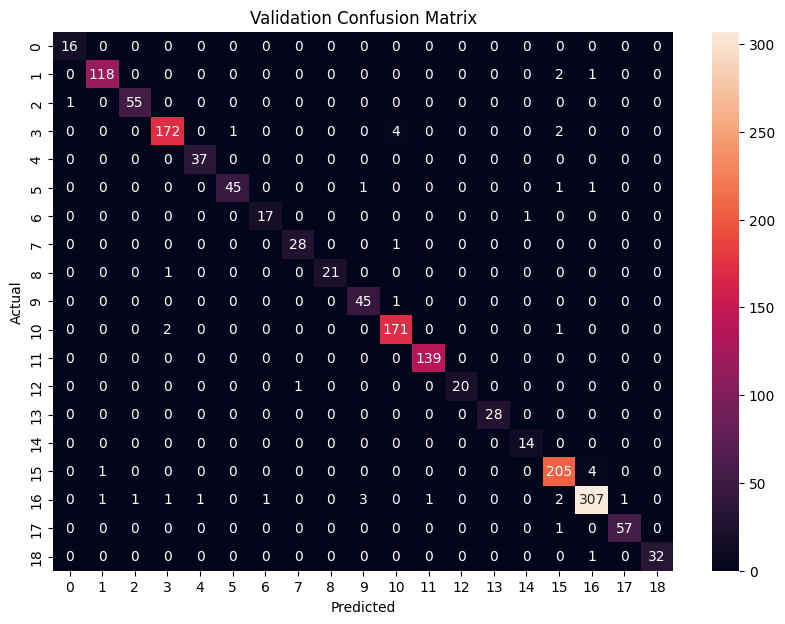

In [23]:
val_outputs = trainer.predict(val_dataset)

if isinstance(val_outputs.predictions, tuple):
    val_logits = val_outputs.predictions[0]
else:
    val_logits = val_outputs.predictions

val_labels = val_outputs.label_ids
val_preds = np.argmax(val_logits, axis=-1)

cm_val = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_val, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Validation Confusion Matrix')
plt.show()